# 01 — Exploratory Data Analysis: UNR-IDD Dataset

This notebook loads the UNR-IDD dataset and performs initial exploration:
- Verify shape, feature count, and class labels
- Class distribution (replicate Fig. 2 from the original paper)
- Descriptive statistics
- Missing values and duplicates check
- Feature correlation heatmap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 150

In [2]:
# TODO: Update this path after downloading the UNR-IDD dataset
# Download from: https://sites.google.com/view/tapadhirdas/unr-idd-dataset
DATASET_PATH = "../data/UNR-IDD.csv"

df = pd.read_csv(DATASET_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (37411, 34)
Columns: ['Switch ID', 'Port Number', 'Received Packets', 'Received Bytes', 'Sent Bytes', 'Sent Packets', 'Port alive Duration (S)', 'Packets Rx Dropped', 'Packets Tx Dropped', 'Packets Rx Errors', 'Packets Tx Errors', 'Delta Received Packets', 'Delta Received Bytes', 'Delta Sent Bytes', 'Delta Sent Packets', 'Delta Port alive Duration (S)', 'Delta Packets Rx Dropped', ' Delta Packets Tx Dropped', 'Delta Packets Rx Errors', 'Delta Packets Tx Errors', 'Connection Point', 'Total Load/Rate', 'Total Load/Latest', 'Unknown Load/Rate', 'Unknown Load/Latest', 'Latest bytes counter', 'is_valid', 'Table ID', 'Active Flow Entries', 'Packets Looked Up', 'Packets Matched', 'Max Size', 'Label', 'Binary Label']


,Switch ID,Port Number,Received Packets,Received Bytes,Sent Bytes,Sent Packets,Port alive Duration (S),Packets Rx Dropped,Packets Tx Dropped,Packets Rx Errors,...,Unknown Load/Latest,Latest bytes counter,is_valid,Table ID,Active Flow Entries,Packets Looked Up,Packets Matched,Max Size,Label,Binary Label
0,of:000000000000000c,Port#:1,132,9181,6311853,238,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
1,of:000000000000000c,Port#:2,187,6304498,15713,171,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
2,of:000000000000000c,Port#:3,235,6311567,8030,58,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
3,of:000000000000000c,Port#:4,59,7878,16439,182,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
4,of:000000000000000a,Port#:1,188,6304547,16497,183,46,0,0,0,...,0,0,True,0,7,489,403,-1,TCP-SYN,Attack


Class counts:
  Blackhole: 8420 (22.5%)
  Diversion: 5615 (15.0%)
  Normal: 3773 (10.1%)
  Overflow: 1022 (2.7%)
  PortScan: 9500 (25.4%)
  TCP-SYN: 9081 (24.3%)


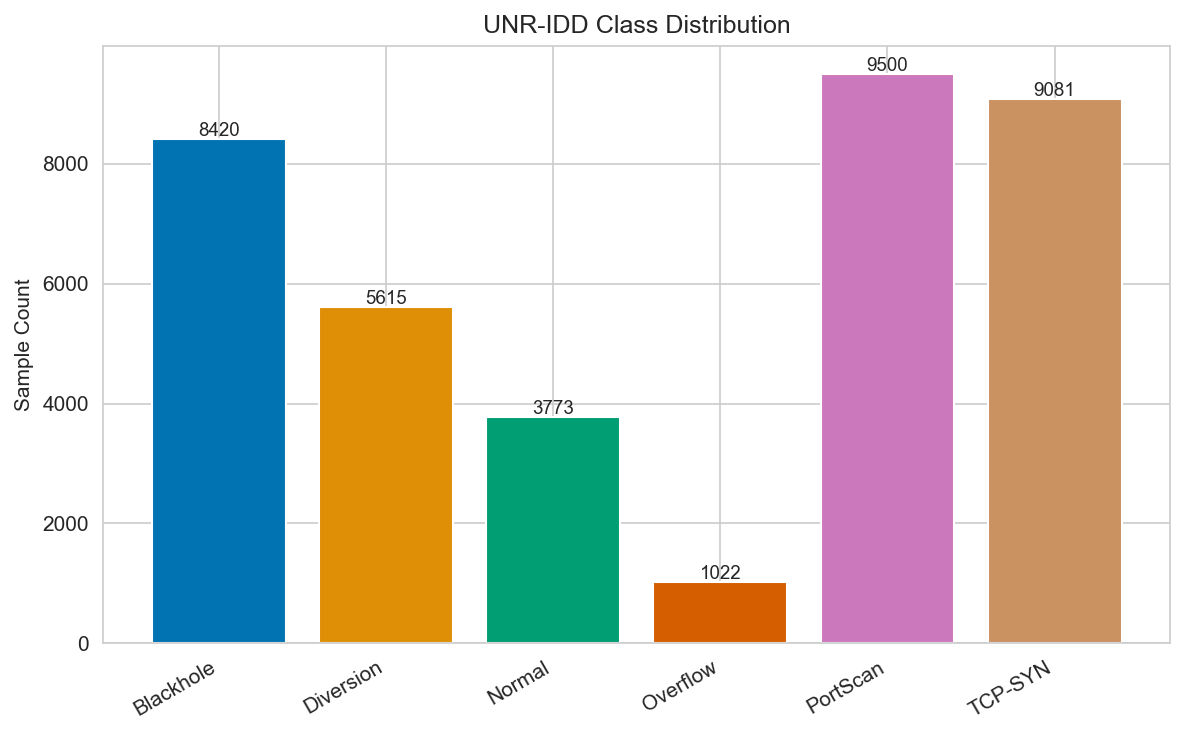

In [3]:
# Class distribution — compare to paper's Fig. 2
CLASS_NAMES = ["Normal", "TCP-SYN", "PortScan", "Overflow", "Blackhole", "Diversion"]
label_col = "Label"  # use the string label column explicitly

class_counts = df[label_col].value_counts().sort_index()
print("Class counts:")
for label, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"  {label}: {count} ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(len(class_counts)), class_counts.values, 
              color=sns.color_palette("colorblind", len(class_counts)))
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, rotation=30, ha="right")
ax.set_ylabel("Sample Count")
ax.set_title("UNR-IDD Class Distribution")
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
# Descriptive statistics
df.describe()

,Received Packets,Received Bytes,Sent Bytes,Sent Packets,Port alive Duration (S),Packets Rx Dropped,Packets Tx Dropped,Packets Rx Errors,Packets Tx Errors,Delta Received Packets,...,Total Load/Rate,Total Load/Latest,Unknown Load/Rate,Unknown Load/Latest,Latest bytes counter,Table ID,Active Flow Entries,Packets Looked Up,Packets Matched,Max Size
count,37411.000000,3.741100e+04,3.741100e+04,37411.000000,37411.000000,37411.0,37411.0,37411.0,37411.0,37411.000000,...,3.741100e+04,3.741100e+04,3.741100e+04,3.741100e+04,3.741100e+04,37411.0,37411.000000,3.741100e+04,3.741100e+04,37411.0
mean,21618.897169,2.647491e+07,2.451212e+07,33626.824009,911.096415,0.0,0.0,0.0,0.0,194.958087,...,1.921455e+04,5.145597e+05,1.921455e+04,5.145597e+05,1.921455e+04,0.0,88.690572,1.008636e+05,1.007444e+05,-1.0
std,65283.170126,3.703044e+07,3.439876e+07,88792.970378,982.113446,0.0,0.0,0.0,0.0,1087.140797,...,1.107441e+05,1.863403e+06,1.107441e+05,1.863403e+06,1.107441e+05,0.0,790.715343,2.350297e+05,2.350284e+05,0.0
min,9.000000,7.860000e+02,5.705000e+03,41.000000,26.000000,0.0,0.0,0.0,0.0,0.000000,...,-1.284277e+06,0.000000e+00,-1.284277e+06,0.000000e+00,-1.284277e+06,0.0,4.000000,8.700000e+01,3.700000e+01,-1.0
25%,329.000000,9.104050e+04,5.775950e+04,347.000000,136.000000,0.0,0.0,0.0,0.0,2.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,5.000000,2.367000e+03,2.272000e+03,-1.0
50%,1170.000000,1.263052e+07,1.262658e+07,1240.000000,259.000000,0.0,0.0,0.0,0.0,4.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,6.000000,7.472000e+03,7.349000e+03,-1.0
75%,3417.000000,3.783230e+07,3.176443e+07,3968.000000,1747.000000,0.0,0.0,0.0,0.0,6.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,8.000000,2.343700e+04,2.322000e+04,-1.0
max,352772.000000,2.715925e+08,2.392430e+08,421598.000000,3317.000000,0.0,0.0,0.0,0.0,15695.000000,...,2.004388e+06,2.606759e+07,2.004388e+06,2.606759e+07,2.004388e+06,0.0,9987.000000,1.012574e+06,1.012439e+06,-1.0


In [5]:
# Missing values and duplicates
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Data types:\n{df.dtypes}")

Missing values per column:
Switch ID                        0
Port Number                      0
Received Packets                 0
Received Bytes                   0
Sent Bytes                       0
Sent Packets                     0
Port alive Duration (S)          0
Packets Rx Dropped               0
Packets Tx Dropped               0
Packets Rx Errors                0
Packets Tx Errors                0
Delta Received Packets           0
Delta Received Bytes             0
Delta Sent Bytes                 0
Delta Sent Packets               0
Delta Port alive Duration (S)    0
Delta Packets Rx Dropped         0
 Delta Packets Tx Dropped        0
Delta Packets Rx Errors          0
Delta Packets Tx Errors          0
Connection Point                 0
Total Load/Rate                  0
Total Load/Latest                0
Unknown Load/Rate                0
Unknown Load/Latest              0
Latest bytes counter             0
is_valid                         0
Table ID                    

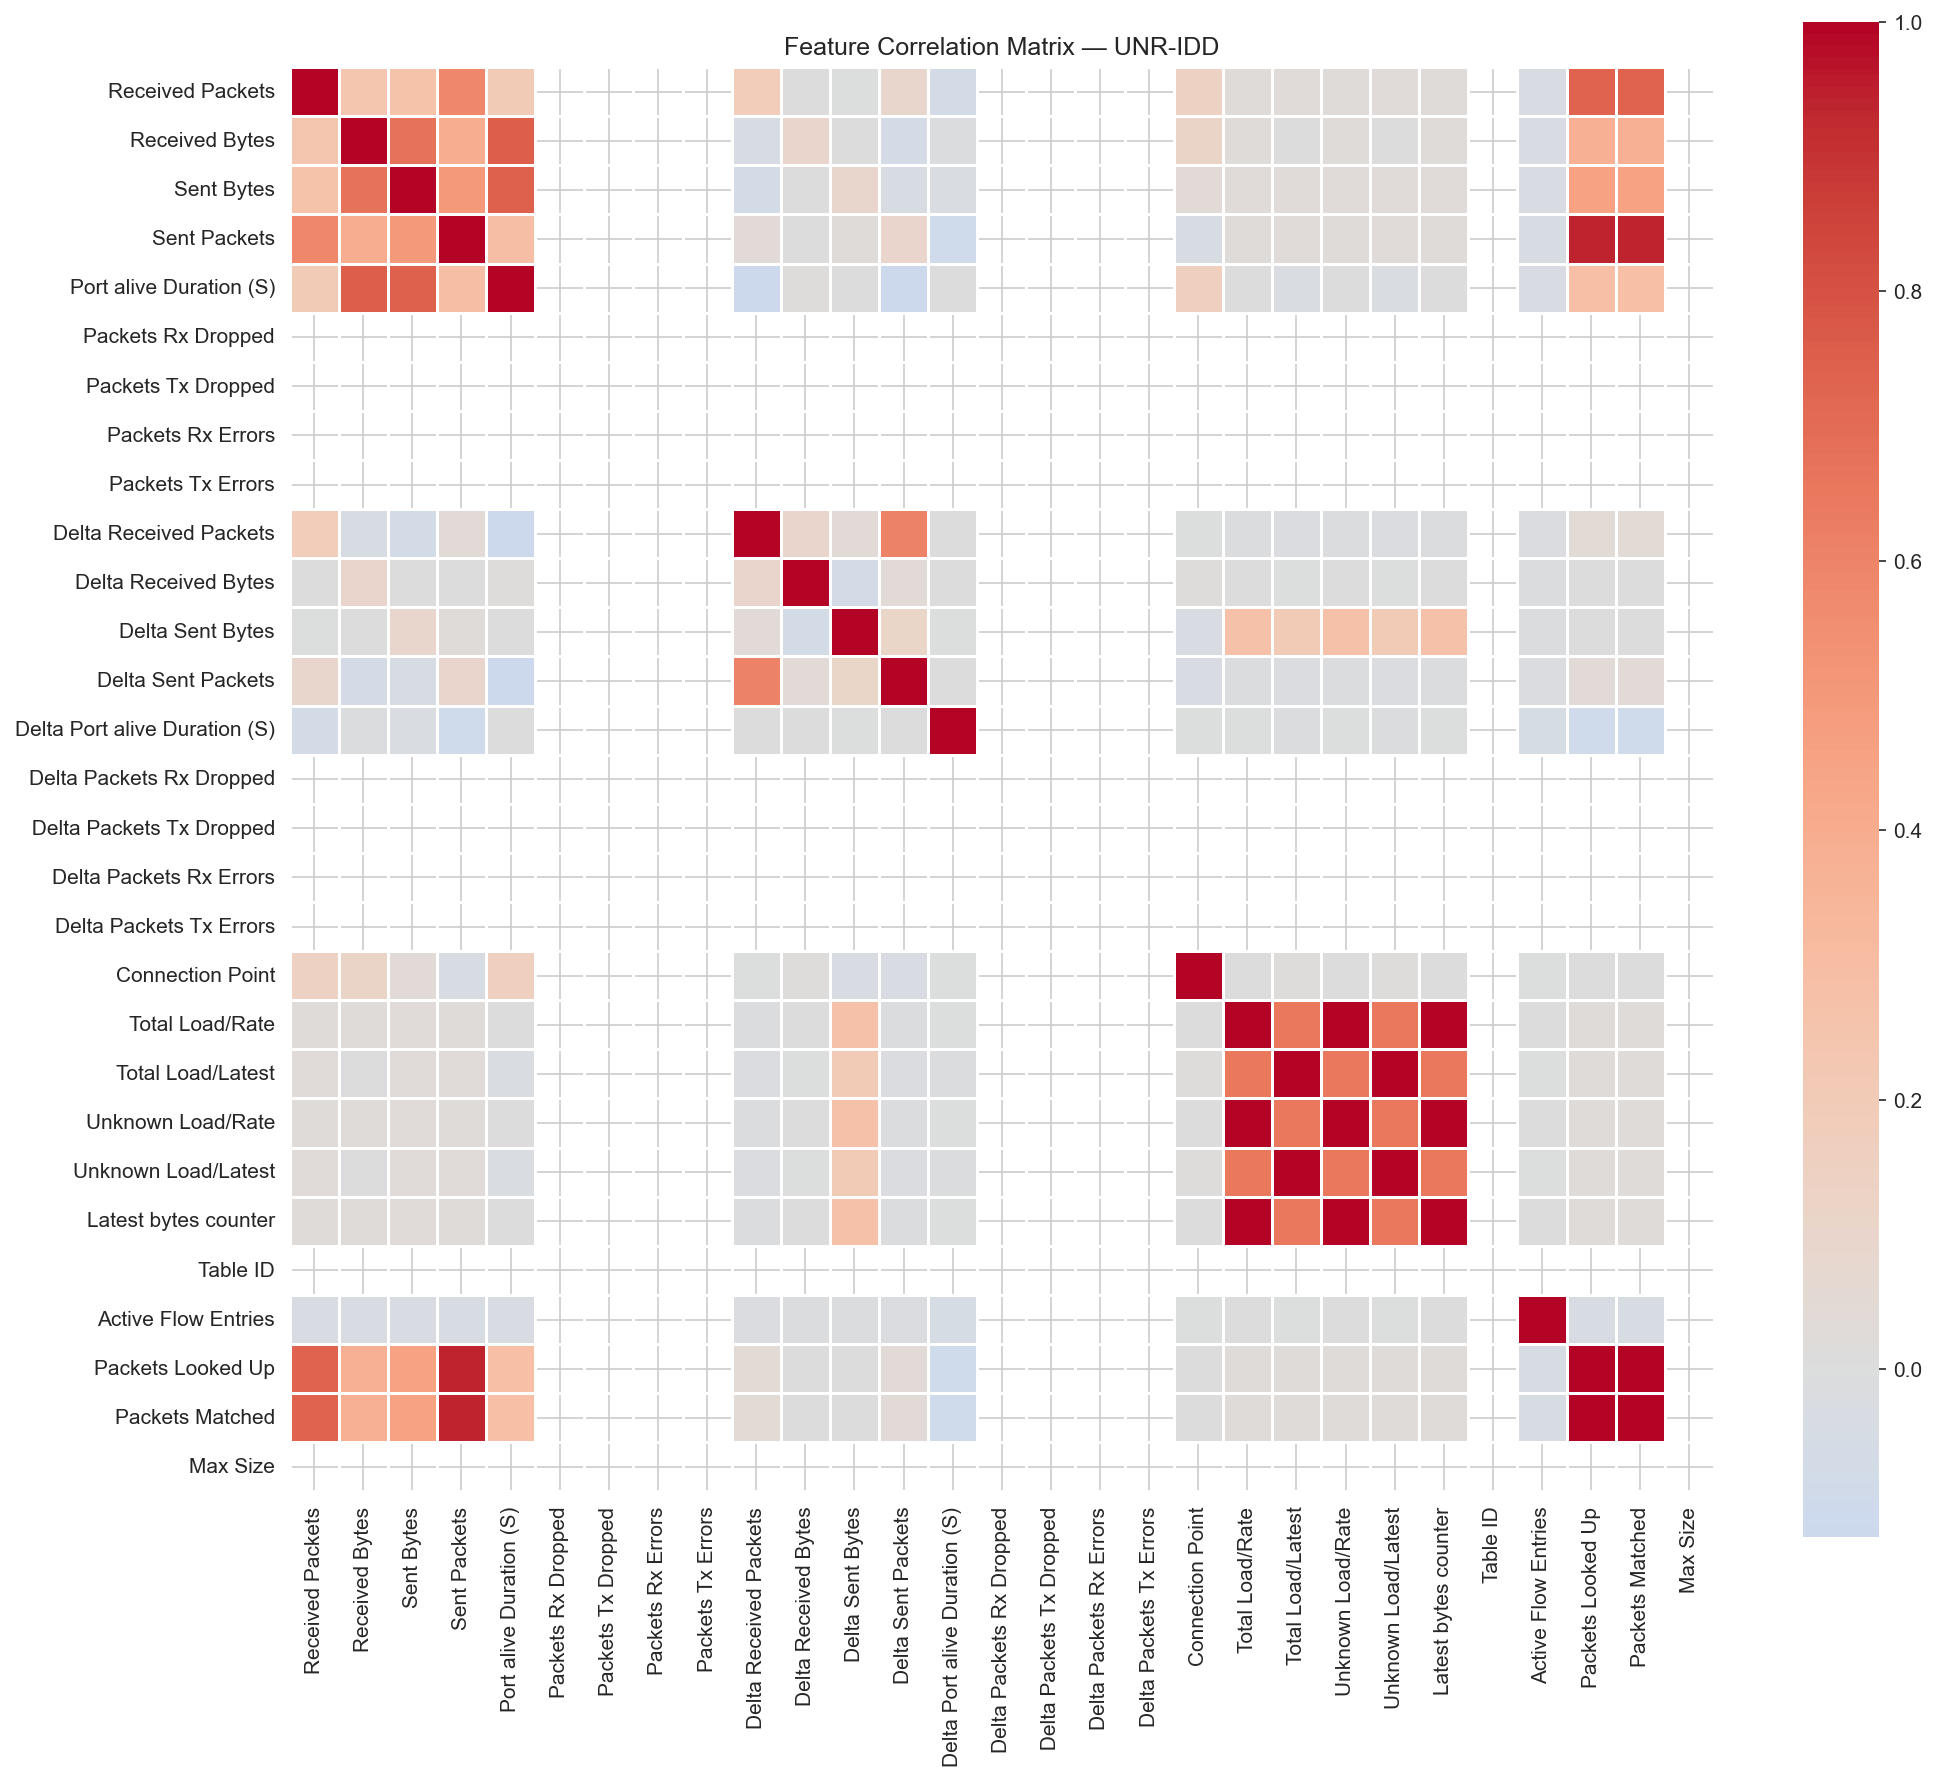

In [6]:
# Feature correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, fmt=".1f",
            annot=False, square=True, linewidths=0.5)
ax.set_title("Feature Correlation Matrix — UNR-IDD")
plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()